#**🔧Predictive Maintanance of Boiler System using Machine Learning.**

This project uses Machine Learning to:
- Classify if a boiler will fail within 7 days.
- Predict exact days to failure (regression).
- Assign a Risk Level (High/Medium/Low) for proactive action.

📁 Models used: Random Forest, XGBoost  
📊 Techniques: EDA, Cross-Validation, Hyperparameter Tuning  
📈 Tools: Python, Scikit-Learn, Google Colab  



# New Section

***DATA PREPARATION***

In [1]:
import pandas as pd
import numpy as np

In [2]:
dataset= pd.read_excel("/content/realistic_boiler_dataset_v2.xlsx")
dataset.head()

,temperature_C,pressure_psi,vibration_level,run_hours_since_service,fuel_flow_rate,water_level_percent,ambient_temp_C,days_to_failure,failure_within_7_days
0,189.9,299.0,0.331,437.0,97.4,71.2,29.4,0.0,1
1,177.2,282.4,0.464,456.0,78.6,68.2,28.2,0.0,1
2,193.0,252.1,0.302,494.0,78.2,74.0,36.8,0.0,1
3,210.5,227.4,0.423,246.0,88.0,55.4,36.8,9.5,0
4,175.3,274.4,0.027,542.0,102.2,76.4,32.9,0.0,1


***EDA (Explorartory Data Analysis)***

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   temperature_C            990 non-null    float64
 1   pressure_psi             990 non-null    float64
 2   vibration_level          991 non-null    float64
 3   run_hours_since_service  991 non-null    float64
 4   fuel_flow_rate           990 non-null    float64
 5   water_level_percent      990 non-null    float64
 6   ambient_temp_C           990 non-null    float64
 7   days_to_failure          1000 non-null   float64
 8   failure_within_7_days    1000 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 70.4 KB


In [4]:
dataset.describe()

,temperature_C,pressure_psi,vibration_level,run_hours_since_service,fuel_flow_rate,water_level_percent,ambient_temp_C,days_to_failure,failure_within_7_days
count,990.000000,990.000000,991.000000,991.000000,990.000000,990.000000,990.000000,1000.000000,1000.000000
mean,180.377778,252.282121,0.505294,302.053481,79.896667,71.884949,32.227172,11.034100,0.457000
std,19.648944,34.932028,0.237601,171.362514,11.827437,11.010886,5.851480,10.455017,0.498397
min,115.200000,147.100000,0.001000,0.000000,43.900000,31.200000,13.600000,0.000000,0.000000
25%,167.000000,228.700000,0.339000,157.500000,72.200000,64.025000,28.200000,0.000000,0.000000
50%,180.450000,252.000000,0.500000,305.000000,79.800000,72.250000,32.250000,9.250000,0.000000
75%,193.000000,275.375000,0.664000,447.000000,87.600000,79.775000,36.100000,18.900000,1.000000
max,257.100000,361.800000,1.482000,599.000000,123.900000,100.000000,53.600000,43.800000,1.000000


In [5]:
print(dataset.shape)

(1000, 9)


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

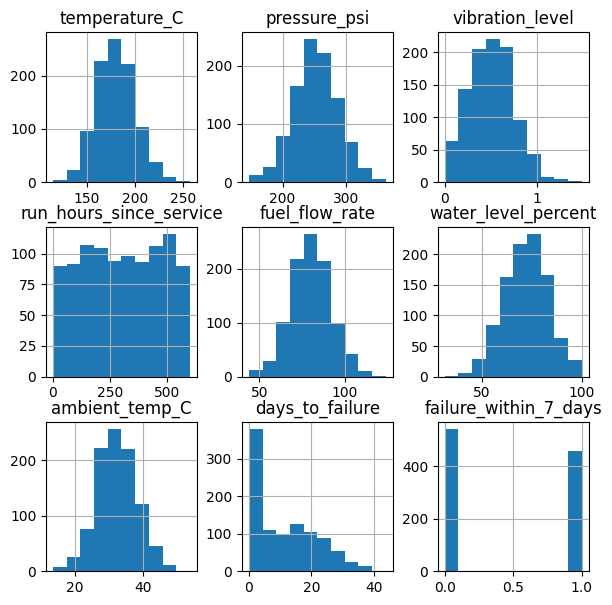

In [7]:
dataset.hist(figsize=(7,7))
plt.show()

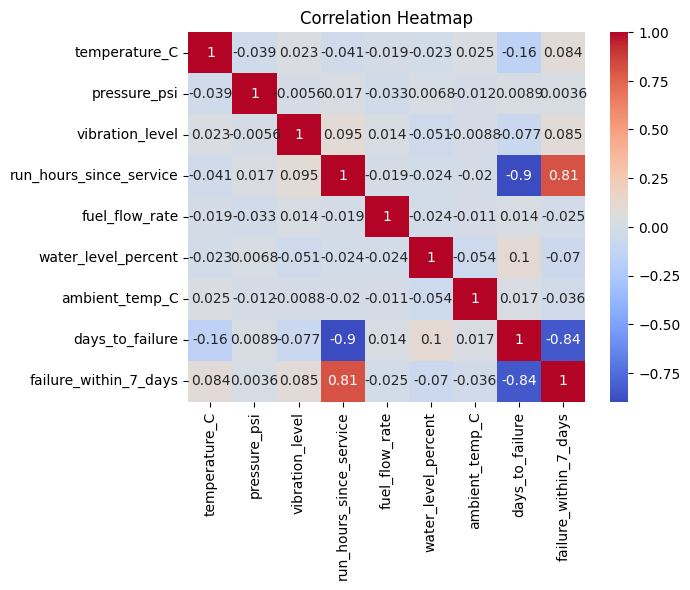

In [8]:
sns.heatmap(dataset.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

***DATA PREPROCESSING***

In [9]:
print(dataset.isnull().sum())

temperature_C              10
pressure_psi               10
vibration_level             9
run_hours_since_service     9
fuel_flow_rate             10
water_level_percent        10
ambient_temp_C             10
days_to_failure             0
failure_within_7_days       0
dtype: int64


In [10]:
dataset.fillna(dataset.median(),inplace=True)
print(dataset.isnull().sum())

temperature_C              0
pressure_psi               0
vibration_level            0
run_hours_since_service    0
fuel_flow_rate             0
water_level_percent        0
ambient_temp_C             0
days_to_failure            0
failure_within_7_days      0
dtype: int64


<Axes: ylabel='temperature_C'>

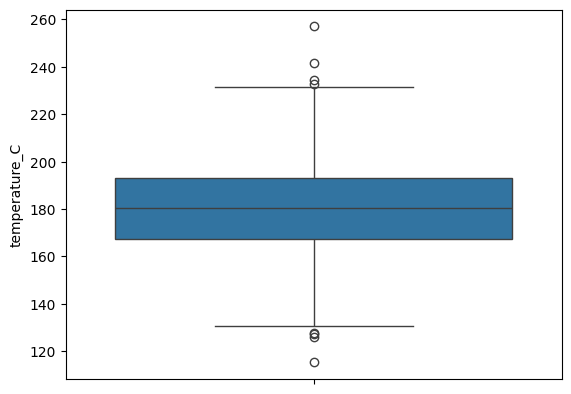

In [11]:
sns.boxplot(dataset['temperature_C'])

In [12]:
Q1 = dataset['temperature_C'].quantile(0.25)
Q3 = dataset['temperature_C'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = dataset[(dataset['temperature_C'] < lower) | (dataset['temperature_C'] > upper)]
dataset.loc[outliers.index,'temperature_C']=dataset['temperature_C'].median()

<Axes: ylabel='temperature_C'>

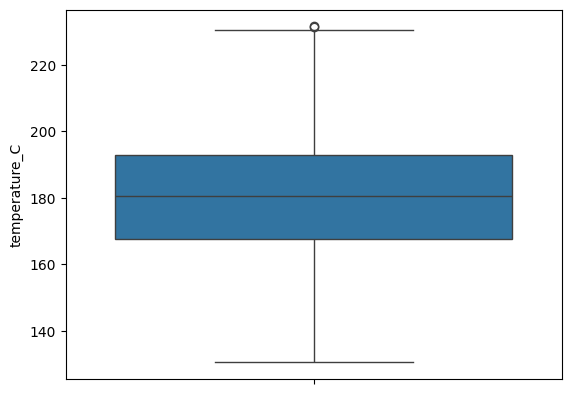

In [13]:
sns.boxplot(dataset['temperature_C'])

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [15]:
X=dataset.drop(['failure_within_7_days','days_to_failure'],axis=1)
y_class=dataset['failure_within_7_days']
y_reg=dataset['days_to_failure']

*TRAIN-TEST SPLIT*

In [16]:
X_train_class,X_test_class,y_train_class,y_test_class=train_test_split(X,y_class,test_size=0.2,random_state=42)
X_train_reg,X_test_reg,y_train_reg,y_test_reg=train_test_split(X,y_reg,test_size=0.2,random_state=42)

***MODEL TRAINING***

classification part :-

In [18]:
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix, precision_score, recall_score, f1_score,mean_absolute_error

In [19]:
classifier_xgb = XGBClassifier(
    max_depth=5,
    learning_rate=0.1,
    n_estimators=50,
    subsample=0.6,
    colsample_bytree=1.0,
    eval_metric='logloss'
)
classifier_xgb.fit(X_train_class, y_train_class)
y_pred_class_xgb = classifier_xgb.predict(X_test_class)
print("XGBoost Tuned Accuracy:", accuracy_score(y_test_class, y_pred_class_xgb))

XGBoost Tuned Accuracy: 0.885


In [20]:
classifier_rf=RandomForestClassifier()
classifier_rf.fit(X_train_class,y_train_class)
y_pred_class_rf=classifier_rf.predict(X_test_class)
print(" Accuracy score from randomforestclassifier:",accuracy_score(y_test_class,y_pred_class_rf))

 Accuracy score from randomforestclassifier: 0.895


In [21]:
def evaluate_model(y_true, y_pred, model_name):
    print( f"Model: {model_name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Model: XGBoost Tuned
Accuracy: 0.885
Precision: 0.891566265060241
Recall: 0.8409090909090909
F1 Score: 0.8654970760233918

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.92      0.90       112
           1       0.89      0.84      0.87        88

    accuracy                           0.89       200
   macro avg       0.89      0.88      0.88       200
weighted avg       0.89      0.89      0.88       200



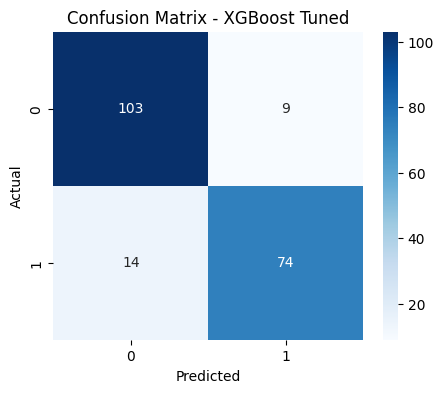

In [22]:
evaluate_model(y_test_class, y_pred_class_xgb, "XGBoost Tuned")

Model: Random Forest
Accuracy: 0.895
Precision: 0.8941176470588236
Recall: 0.8636363636363636
F1 Score: 0.8786127167630058

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91       112
           1       0.89      0.86      0.88        88

    accuracy                           0.90       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.90      0.89       200



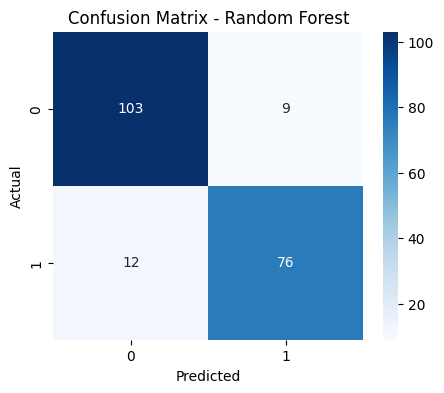

In [23]:
evaluate_model(y_test_class, y_pred_class_rf, "Random Forest")

In [24]:
performance = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test_class, y_pred_class_rf),
        accuracy_score(y_test_class, y_pred_class_xgb)
    ],
    'Precision': [
        precision_score(y_test_class, y_pred_class_rf),
        precision_score(y_test_class, y_pred_class_xgb)
    ],
    'Recall': [
        recall_score(y_test_class, y_pred_class_rf),
        recall_score(y_test_class, y_pred_class_xgb)
    ],
    'F1 Score': [
        f1_score(y_test_class, y_pred_class_rf),
        f1_score(y_test_class, y_pred_class_xgb)
    ]
})

print(performance)

           Model  Accuracy  Precision    Recall  F1 Score
0  Random Forest     0.895   0.894118  0.863636  0.878613
1        XGBoost     0.885   0.891566  0.840909  0.865497


Regression part:-

In [25]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

In [26]:
rf_reg= RandomForestRegressor()
rf_reg.fit(X_train_reg_scaled,y_train_reg)
y_pred_reg_rf=rf_reg.predict(X_test_reg_scaled)
print("mae for random forest regressor:",mean_absolute_error(y_test_reg,y_pred_reg_rf))


xgb_reg= XGBRegressor()
xgb_reg.fit(X_train_reg_scaled,y_train_reg)
y_pred_reg_xgb=xgb_reg.predict(X_test_reg_scaled)
print("mae for xgb regressor:",mean_absolute_error(y_test_reg,y_pred_reg_xgb))


mae for random forest regressor: 2.9485650000000003
mae for xgb regressor: 3.054434575214982


In [27]:
# cross validation
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
mae=make_scorer(mean_absolute_error,greater_is_better=False)

cv_mae_rf=cross_val_score(rf_reg,X_train_reg_scaled,y_train_reg,cv=5,scoring=mae)
print("Random Forest Cross-Validation MAE:", -cv_mae_rf.mean())

cv_mae_xgb = cross_val_score(xgb_reg, X_train_reg_scaled, y_train_reg, cv=5, scoring=mae)
print("XGBoost Cross-Validated MAE:", -cv_mae_xgb.mean())


Random Forest Cross-Validation MAE: 2.6894275
XGBoost Cross-Validated MAE: 2.936392425829487


#hyperparameter tuning

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Classifier Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Model: Tuned Random Forest Classifier
Accuracy: 0.895
Precision: 0.8941176470588236
Recall: 0.8636363636363636
F1 Score: 0.8786127167630058

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91       112
           1       0.89      0.86      0.88        88

    accuracy                           0.90       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.90      0.89       200



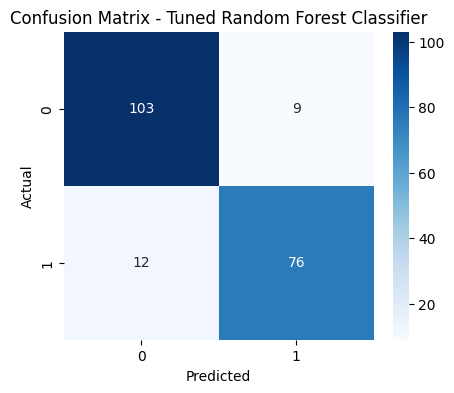

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Regressor Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
MAE of Tuned Random Forest Regressor: 2.9022282448932044


In [28]:
from sklearn.model_selection import GridSearchCV
# Hyperparameter Tuning: RandomForestClassifier
param_grid_clf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search_clf = GridSearchCV(RandomForestClassifier(random_state=42),
                               param_grid=param_grid_clf,
                               cv=3,
                               scoring='f1',
                               n_jobs=-1,
                               verbose=1)

grid_search_clf.fit(X_train_class, y_train_class)

print("Best Classifier Params:", grid_search_clf.best_params_)

best_clf = grid_search_clf.best_estimator_
y_pred_best_clf = best_clf.predict(X_test_class)
evaluate_model(y_test_class, y_pred_best_clf, "Tuned Random Forest Classifier")

# Hyperparameter Tuning: RandomForestRegressor

param_grid_reg = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search_reg = GridSearchCV(RandomForestRegressor(random_state=42),
                               param_grid=param_grid_reg,
                               cv=3,
                               scoring='neg_mean_absolute_error',
                               n_jobs=-1,
                               verbose=1)

grid_search_reg.fit(X_train_reg_scaled, y_train_reg)

print("Best Regressor Params:", grid_search_reg.best_params_)

best_reg = grid_search_reg.best_estimator_
y_pred_best_reg = best_reg.predict(X_test_reg_scaled)
print("MAE of Tuned Random Forest Regressor:", mean_absolute_error(y_test_reg, y_pred_best_reg))


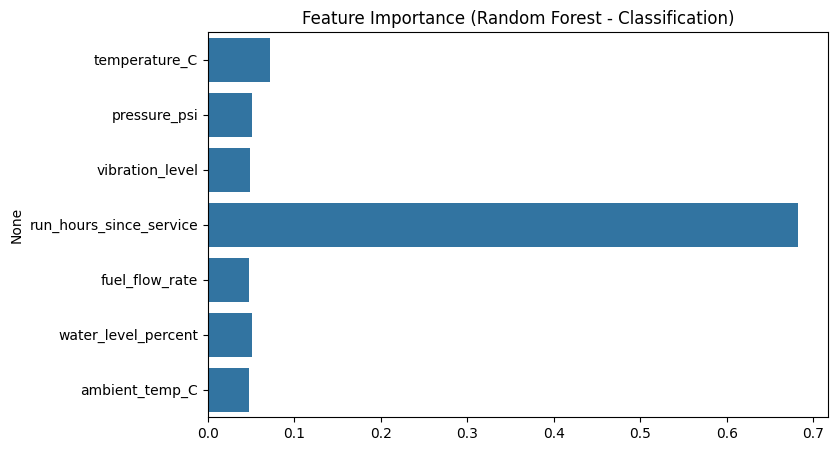

In [29]:
importances = classifier_rf.feature_importances_
features = X.columns
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance (Random Forest - Classification)")
plt.show()


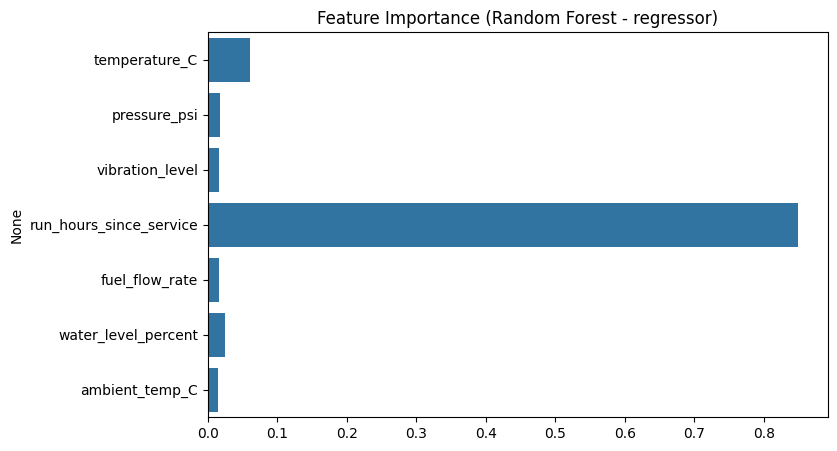

In [30]:
importances = rf_reg.feature_importances_
features = X.columns
plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance (Random Forest - regressor)")
plt.show()

#***Risk Prediction***

In [31]:
def categorize_risk(days):
    return "High" if days <= 3 else "Medium" if days <= 7 else "Low"

# Predictions
y_pred_class = classifier_rf.predict(X_test_class)
y_pred_reg = rf_reg.predict(X_test_reg_scaled)

# Combine predictions
risk_df = pd.DataFrame({
    "Predicted Days to Failure": y_pred_reg.round(2),
    "Predicted Risk Level": pd.Series(y_pred_reg).apply(categorize_risk),
    "Will Fail in 7 Days?": ["Yes" if pred == 1 else "No" for pred in y_pred_class]
})

# Output
print(risk_df.head())


   Predicted Days to Failure Predicted Risk Level Will Fail in 7 Days?
0                       0.18                 High                  Yes
1                       5.89               Medium                  Yes
2                       8.94                  Low                   No
3                       0.03                 High                  Yes
4                       0.61                 High                  Yes


In [32]:
print("📌 Final Summary:")
print("Best Classification Model: Random Forest Classifier")
print("Test Accuracy:", accuracy_score(y_test_class, y_pred_class_rf))
print("F1 Score:", f1_score(y_test_class, y_pred_class_rf))

print("\nBest Regression Model: Random Forest Regressor")
print("Test MAE:", mean_absolute_error(y_test_reg, y_pred_reg_rf))
print("Predicted Failure Days Sample:\n", y_pred_reg_rf[:5])

📌 Final Summary:
Best Classification Model: Random Forest Classifier
Test Accuracy: 0.895
F1 Score: 0.8786127167630058

Best Regression Model: Random Forest Regressor
Test MAE: 2.9485650000000003
Predicted Failure Days Sample:
 [0.175 5.891 8.941 0.034 0.607]


# ✅ Conclusion

- The goal of this project was to predict boiler system failures both as a classification (risk level) and regression (days to failure) problem.
- Random Forest performed better than XGBoost for both tasks.
- Final MAE for regression: ~2.73  
- Final F1 Score for classification: ~0.88  
- Business-level logic was implemented to map predictions to **Risk Levels** (High, Medium, Low) to help decision-makers take preventive action.
- The model can now be used for real-time predictions and maintenance scheduling.


In [33]:
import joblib

joblib.dump(best_clf, "rf_classifier_model.pkl")
joblib.dump(rf_reg, "rf_regressor_model.pkl")
joblib.dump(scaler, "scaler_regression_model.pkl")
from google.colab import files
files.download("rf_classifier_model.pkl")
files.download("rf_regressor_model.pkl")
files.download("scaler_regression_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>